# Rede Neural

Imports

In [13]:
from src.objetos import Dados, camada_densa, rede_neural

Caminho contendo os dados das imagens e os rótulos correspondentes.

In [14]:
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

Inicialização dos dados

In [15]:
dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)

Método de separação dos dados

In [16]:
dados._holdout(0.6, 0.2)

Parâmetros da rede neural

In [17]:
epocas = 500
taxa_aprendizado = 2
lambda_reg = 0.1
# [A,B,C] : A -> B -> C
arquitetura_camadas = [400, 25, 10]

Inicialização das camadas

In [18]:
camadas = []

for i in range(len(arquitetura_camadas)-2):
    camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[i], 
        tamanho_saida=arquitetura_camadas[i+1],
        funcao_de_ativacao='sigmoid'
        )
    camadas.append(camada)
# Aplica softmax na ultima camada
camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[-2], 
        tamanho_saida=arquitetura_camadas[-1],
        funcao_de_ativacao='softmax'
        )
camadas.append(camada)


Inicialização da rede neural

In [19]:
rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

Treinamento da rede

In [20]:
rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_reg
)

Leitura dos Logs

In [21]:
import pandas as pd

logs = pd.read_csv("log_treinamento.csv")

# Resultado

Acurácia com base no conjunto de teste

In [22]:
import numpy as np
y_teste = rede._avalia(dados.conjunto_teste[0])
classes_pred = np.argmax(y_teste, axis=0) + 1
classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
acertos = np.sum(classes_pred == classes_real)
num_amostras = dados.conjunto_teste[0].shape[1]

acuracia_modelo = acertos/num_amostras

print(acuracia_modelo)

0.927


Imagens do conjunto de teste classificadas incorretamente

In [23]:
for i in range(num_amostras):
    if (classes_pred[i] != classes_real[i]):
        comparacao = np.all(dados.pacote_dados == dados.conjunto_teste[0].T[i], axis=1)
        indice = np.where(comparacao)[0]
        print(indice)
        print(f"Classe prevista: {classes_pred[i]}")
        print(f"Classe real: {classes_real[i]}")

[1707]
Classe prevista: 1
Classe real: 3
[1528]
Classe prevista: 5
Classe real: 3
[1658]
Classe prevista: 2
Classe real: 3
[2520]
Classe prevista: 6
Classe real: 5
[2958]
Classe prevista: 9
Classe real: 5
[1476]
Classe prevista: 7
Classe real: 2
[4494]
Classe prevista: 9
Classe real: 8
[2171]
Classe prevista: 9
Classe real: 4
[4627]
Classe prevista: 5
Classe real: 9
[3725]
Classe prevista: 10
Classe real: 7
[4100]
Classe prevista: 1
Classe real: 8
[1189]
Classe prevista: 8
Classe real: 2
[1556]
Classe prevista: 5
Classe real: 3
[3174]
Classe prevista: 5
Classe real: 6
[3451]
Classe prevista: 4
Classe real: 6
[3457]
Classe prevista: 5
Classe real: 6
[2263]
Classe prevista: 10
Classe real: 4
[1368]
Classe prevista: 10
Classe real: 2
[2560]
Classe prevista: 8
Classe real: 5
[2282]
Classe prevista: 8
Classe real: 4
[569]
Classe prevista: 8
Classe real: 1
[4593]
Classe prevista: 10
Classe real: 9
[1490]
Classe prevista: 7
Classe real: 2
[1570]
Classe prevista: 5
Classe real: 3
[2704]
Classe

Gráfico do custo de treinamento e do custo de validação em função da época de treinamento

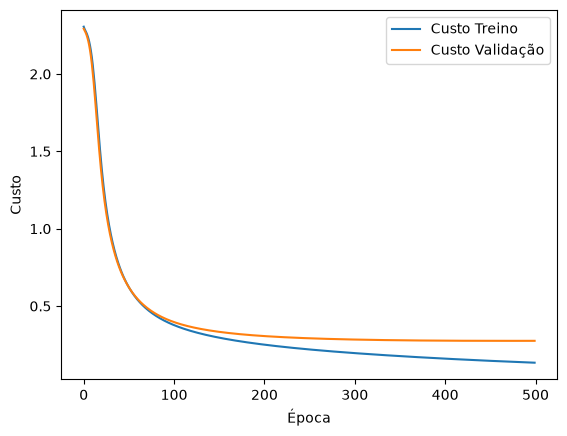

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(logs["epoca"],logs["custo_treinamento"], label="Custo Treino")
plt.plot(logs["epoca"],logs["custo_validacao"], label="Custo Validação")
plt.xlabel("Época")
plt.ylabel("Custo")
plt.legend()
plt.show()